# Satellite Lifetime Prediction and Orbital Clustering

This notebook applies supervised and unsupervised machine-learning methods to the curated satellite dataset.

The analysis has two main objectives:

1. **Supervised learning:** predict whether a satellite has a short, medium, or long reported expected lifetime.
2. **Unsupervised learning:** identify natural groups of satellites based on their physical and orbital characteristics.

The training, validation, and test datasets were created in the data-curation stage. Missing-value imputation, categorical encoding, and numerical scaling were fitted using the training set only and then applied unchanged to the validation and test sets.

## Imports and Configuration

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import CalibratedClassifierCV
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight

from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real

from xgboost import XGBClassifier

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

warnings.filterwarnings(
    "ignore",
    message="The objective has been evaluated at point .* before.*",
    category=UserWarning,
    module="skopt.optimizer.optimizer",
)


## Data Loading

The curated datasets contain 20 model-ready features and the target variable `LIFETIME_CLASS`.

The three subsets are kept separate throughout model development:

- the **training set** is used to fit the models;
- the **validation set** is used to compare models and hyperparameter configurations;
- the **test set** is reserved for the final evaluation of the selected model.

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")

train_df = pd.read_csv(PROCESSED_DATA_DIR / "train.csv")
validation_df = pd.read_csv(PROCESSED_DATA_DIR / "validation.csv")
test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")

print(f"Training set:   {train_df.shape}")
print(f"Validation set: {validation_df.shape}")
print(f"Test set:       {test_df.shape}")

Training set:   (3210, 21)
Validation set: (1070, 21)
Test set:       (1071, 21)


In [3]:
assert list(train_df.columns) == list(validation_df.columns)
assert list(train_df.columns) == list(test_df.columns)

assert train_df.isna().sum().sum() == 0
assert validation_df.isna().sum().sum() == 0
assert test_df.isna().sum().sum() == 0

print("All datasets have matching columns and no missing values.")

All datasets have matching columns and no missing values.


## Supervised Learning

### Problem Setup

The target variable is `LIFETIME_CLASS`, which contains three categories:

- `SHORT`
- `MEDIUM`
- `LONG`

These classes were defined during data curation from the reported expected lifetime using thresholds estimated exclusively from the training data.

The remaining columns are used as predictive features.

In [4]:
TARGET = "LIFETIME_CLASS"

X_train = train_df.drop(columns=TARGET)
y_train = train_df[TARGET]

X_validation = validation_df.drop(columns=TARGET)
y_validation = validation_df[TARGET]

X_test = test_df.drop(columns=TARGET)
y_test = test_df[TARGET]

In [5]:
print(f"Number of features: {X_train.shape[1]}")

display(
    pd.DataFrame({
        "Train": y_train.value_counts(),
        "Validation": y_validation.value_counts(),
        "Test": y_test.value_counts(),
    }).reindex(["SHORT", "MEDIUM", "LONG"])
)

Number of features: 20


,Train,Validation,Test
LIFETIME_CLASS,,,
SHORT,252,84,89
MEDIUM,2514,830,840
LONG,444,156,142


The class distribution is clearly imbalanced, with `MEDIUM` representing the majority of observations.

For this reason, model evaluation will not rely on accuracy alone. In particular, **macro F1-score** and **balanced accuracy** will be used to evaluate performance across all three classes, while multiclass ROC-AUC will provide an additional measure based on predicted probabilities.

### Random Forest

We begin with a Random Forest classifier as a tree-based ensemble baseline.

Random Forest can capture nonlinear relationships and interactions between features without requiring additional transformations. Since the target classes are imbalanced, we use `class_weight="balanced"` so that errors in the minority classes receive greater importance during training.

We first use stratified cross-validation on the training set to obtain an auxiliary estimate of model stability. Model comparison and selection will subsequently be based on the independent validation set.

In [6]:
rf = RandomForestClassifier(
    random_state=RANDOM_SEED,
    class_weight="balanced",
)

In [7]:
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_SEED,
)

rf_cv_scores = cross_validate(
    rf,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "f1_macro": "f1_macro",
        "balanced_accuracy": "balanced_accuracy",
        "roc_auc": "roc_auc_ovr",
    },
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    "Mean": [
        rf_cv_scores["test_f1_macro"].mean(),
        rf_cv_scores["test_balanced_accuracy"].mean(),
        rf_cv_scores["test_roc_auc"].mean(),
    ],
    "Std": [
        rf_cv_scores["test_f1_macro"].std(),
        rf_cv_scores["test_balanced_accuracy"].std(),
        rf_cv_scores["test_roc_auc"].std(),
    ],
}, index=[
    "Macro F1",
    "Balanced Accuracy",
    "ROC-AUC OvR",
])

display(cv_summary.round(4))

,Mean,Std
Macro F1,0.9472,0.0122
Balanced Accuracy,0.9590,0.0148
ROC-AUC OvR,0.9975,0.0025


In [8]:
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [9]:
y_pred_rf = rf.predict(X_validation)
y_proba_rf = rf.predict_proba(X_validation)

rf_validation_metrics = pd.Series({
    "Macro F1": f1_score(
        y_validation,
        y_pred_rf,
        average="macro",
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_validation,
        y_pred_rf,
    ),
    "ROC-AUC OvR": roc_auc_score(
        y_validation,
        y_proba_rf,
        multi_class="ovr",
        labels=rf.classes_,
    ),
})

display(
    rf_validation_metrics
    .round(4)
    .to_frame("Random Forest")
)

,Random Forest
Macro F1,0.9528
Balanced Accuracy,0.9617
ROC-AUC OvR,0.9988


In [10]:
print(
    classification_report(
        y_validation,
        y_pred_rf,
        digits=3,
    )
)

              precision    recall  f1-score   support

        LONG      0.943     0.962     0.952       156
      MEDIUM      0.991     0.983     0.987       830
       SHORT      0.898     0.940     0.919        84

    accuracy                          0.977      1070
   macro avg      0.944     0.962     0.953      1070
weighted avg      0.977     0.977     0.977      1070



The baseline Random Forest already shows strong and consistent performance.

Cross-validation and validation-set results are closely aligned, suggesting that the model is stable across different subsets of the training data. Performance is also strong for the minority classes, although `SHORT` remains the most difficult class to predict.

Because the baseline model is already highly competitive, hyperparameter optimization is expected to provide only incremental improvements rather than a major change in performance.

The cross-validation scores are used as an auxiliary stability check. Since the preprocessing pipeline was fitted once on the complete supervised training split during data curation, the independent validation set remains the primary reference for model selection.

#### Hyperparameter Optimization

The baseline model performs well with default hyperparameters, but we can test whether a more suitable Random Forest configuration improves minority-class performance or overall balance.

Bayesian optimization is used to explore a compact hyperparameter space more efficiently than an exhaustive grid search.

Since class balance is important in this problem, **macro F1-score** is used as the optimization objective.

In [11]:
rf_search_space = {
    "n_estimators": Integer(100, 1000),
    "max_depth": Categorical(
        [None] + list(range(3, 31))
    ),
    "min_samples_split": Integer(2, 10),
    "min_samples_leaf": Integer(1, 10),
    "max_features": Categorical(["sqrt", "log2"]),
}

In [12]:
rf_search = BayesSearchCV(
    estimator=RandomForestClassifier(
        random_state=RANDOM_SEED,
        class_weight="balanced",
    ),
    search_spaces=rf_search_space,
    n_iter=30,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

rf_search.fit(X_train, y_train)

print("Best parameters:")
display(pd.Series(rf_search.best_params_).to_frame("Value"))

print(
    f"Best cross-validation macro F1: "
    f"{rf_search.best_score_:.4f}"
)

Best parameters:


,Value
max_depth,None
max_features,log2
min_samples_leaf,1
min_samples_split,2
n_estimators,100


Best cross-validation macro F1: 0.9472


In [13]:
rf_optimized = rf_search.best_estimator_

y_pred_rf_opt = rf_optimized.predict(X_validation)
y_proba_rf_opt = rf_optimized.predict_proba(X_validation)

rf_optimized_metrics = pd.Series({
    "Macro F1": f1_score(
        y_validation,
        y_pred_rf_opt,
        average="macro",
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_validation,
        y_pred_rf_opt,
    ),
    "ROC-AUC OvR": roc_auc_score(
        y_validation,
        y_proba_rf_opt,
        multi_class="ovr",
        labels=rf_optimized.classes_,
    ),
})

rf_comparison = pd.concat(
    [
        rf_validation_metrics.rename("Baseline"),
        rf_optimized_metrics.rename("Optimized"),
    ],
    axis=1,
)

display(rf_comparison.round(4))

,Baseline,Optimized
Macro F1,0.9528,0.9528
Balanced Accuracy,0.9617,0.9617
ROC-AUC OvR,0.9988,0.9988


Hyperparameter optimization does not improve the Random Forest performance. The selected configuration is very close to the default model, and both produce identical validation metrics.

This suggests that the strong performance is not driven by a narrowly tuned hyperparameter configuration. The baseline Random Forest is therefore retained as the representative Random Forest model for subsequent comparison.

### XGBoost

We next evaluate XGBoost, a gradient-boosted tree model.

Unlike Random Forest, which builds many trees largely independently, gradient boosting constructs trees sequentially so that each new tree focuses on errors made by the previous ensemble.

Because XGBoost internally expects numerical class labels, the lifetime categories are encoded before training. Class-balanced sample weights are used to reduce the influence of the majority `MEDIUM` class.

In [14]:
label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)
y_validation_xgb = label_encoder.transform(y_validation)

class_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_),
    )
)

class_mapping


{'LONG': np.int64(0), 'MEDIUM': np.int64(1), 'SHORT': np.int64(2)}

In [15]:
xgb_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_xgb,
)

In [16]:
xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

xgb.fit(
    X_train,
    y_train_xgb,
    sample_weight=xgb_sample_weights,
)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklear

In [17]:
y_pred_xgb_encoded = xgb.predict(X_validation)
y_proba_xgb = xgb.predict_proba(X_validation)

y_pred_xgb = label_encoder.inverse_transform(
    y_pred_xgb_encoded
)

In [18]:
xgb_validation_metrics = pd.Series({
    "Macro F1": f1_score(
        y_validation,
        y_pred_xgb,
        average="macro",
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_validation,
        y_pred_xgb,
    ),
    "ROC-AUC OvR": roc_auc_score(
        y_validation_xgb,
        y_proba_xgb,
        multi_class="ovr",
    ),
})

display(
    xgb_validation_metrics
    .round(4)
    .to_frame("XGBoost")
)

,XGBoost
Macro F1,0.9465
Balanced Accuracy,0.9569
ROC-AUC OvR,0.9984


In [19]:
print(
    classification_report(
        y_validation,
        y_pred_xgb,
        digits=3,
    )
)

              precision    recall  f1-score   support

        LONG      0.943     0.962     0.952       156
      MEDIUM      0.990     0.981     0.985       830
       SHORT      0.876     0.929     0.902        84

    accuracy                          0.974      1070
   macro avg      0.937     0.957     0.947      1070
weighted avg      0.974     0.974     0.974      1070



The baseline XGBoost model also achieves strong validation performance, although it is slightly below Random Forest in macro F1-score and balanced accuracy.

The largest difference appears in the minority `SHORT` class, where Random Forest achieves a somewhat better balance between precision and recall. Both models nevertheless obtain very high multiclass ROC-AUC values.

Before comparing the tree-based models definitively, we perform a compact hyperparameter search to determine whether XGBoost benefits from additional tuning.

#### Hyperparameter Optimization

XGBoost performance depends on the interaction between tree complexity, learning rate, and the number of boosting iterations.

We therefore explore a compact set of influential hyperparameters using Bayesian optimization. As with Random Forest, macro F1-score is used as the optimization objective to give equal importance to the three lifetime classes.

In [20]:
xgb_search_space = {
    "n_estimators": Integer(100, 600),
    "max_depth": Integer(2, 8),
    "learning_rate": Real(
        0.01,
        0.3,
        prior="log-uniform",
    ),
    "min_child_weight": Integer(1, 10),
    "subsample": Real(0.6, 1.0),
    "colsample_bytree": Real(0.6, 1.0),
}

In [21]:
xgb_search = BayesSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_SEED,
        n_jobs=1,
    ),
    search_spaces=xgb_search_space,
    n_iter=30,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

xgb_search.fit(
    X_train,
    y_train_xgb,
    sample_weight=xgb_sample_weights,
)

print("Best parameters:")
display(
    pd.Series(
        xgb_search.best_params_
    ).to_frame("Value")
)

print(
    f"Best cross-validation macro F1: "
    f"{xgb_search.best_score_:.4f}"
)

Best parameters:


,Value
colsample_bytree,0.608792
learning_rate,0.055072
max_depth,2.000000
min_child_weight,1.000000
n_estimators,241.000000
subsample,0.726237


Best cross-validation macro F1: 0.9669


In [22]:
xgb_optimized = xgb_search.best_estimator_

y_pred_xgb_opt_encoded = xgb_optimized.predict(
    X_validation
)

y_proba_xgb_opt = xgb_optimized.predict_proba(
    X_validation
)

y_pred_xgb_opt = label_encoder.inverse_transform(
    y_pred_xgb_opt_encoded
)

xgb_optimized_metrics = pd.Series({
    "Macro F1": f1_score(
        y_validation,
        y_pred_xgb_opt,
        average="macro",
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_validation,
        y_pred_xgb_opt,
    ),
    "ROC-AUC OvR": roc_auc_score(
        y_validation_xgb,
        y_proba_xgb_opt,
        multi_class="ovr",
    ),
})

xgb_comparison = pd.concat(
    [
        xgb_validation_metrics.rename("Baseline"),
        xgb_optimized_metrics.rename("Optimized"),
    ],
    axis=1,
)

display(xgb_comparison.round(4))

,Baseline,Optimized
Macro F1,0.9465,0.9410
Balanced Accuracy,0.9569,0.9674
ROC-AUC OvR,0.9984,0.9977


Hyperparameter optimization improves the cross-validation macro F1-score, but this improvement does not transfer to the independent validation set.

The optimized model achieves higher balanced accuracy by increasing recall for the minority classes, particularly `SHORT`, but this comes at the cost of lower precision. As a result, its validation macro F1-score decreases from 0.9465 to 0.9410.

Since macro F1 is the primary model-selection metric, the baseline XGBoost model is retained for the final comparison.

### Support Vector Machine

The third supervised model is a Support Vector Machine with a radial basis function (RBF) kernel.

Unlike the tree-based models, SVM constructs nonlinear decision boundaries based on distances between observations in feature space. This makes feature scaling particularly important; the input features were therefore scaled during the data-curation stage.

Class weights are balanced to reduce the influence of the majority `MEDIUM` class.

In [23]:
svm = CalibratedClassifierCV(
    estimator=SVC(
        kernel="rbf",
        class_weight="balanced",
    ),
    ensemble=False,
)

In [24]:
svm_cv_scores = cross_validate(
    svm,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "f1_macro": "f1_macro",
        "balanced_accuracy": "balanced_accuracy",
        "roc_auc": "roc_auc_ovr",
    },
    n_jobs=-1,
)

svm_cv_summary = pd.DataFrame({
    "Mean": [
        svm_cv_scores["test_f1_macro"].mean(),
        svm_cv_scores["test_balanced_accuracy"].mean(),
        svm_cv_scores["test_roc_auc"].mean(),
    ],
    "Std": [
        svm_cv_scores["test_f1_macro"].std(),
        svm_cv_scores["test_balanced_accuracy"].std(),
        svm_cv_scores["test_roc_auc"].std(),
    ],
}, index=[
    "Macro F1",
    "Balanced Accuracy",
    "ROC-AUC OvR",
])

display(svm_cv_summary.round(4))

,Mean,Std
Macro F1,0.9011,0.0280
Balanced Accuracy,0.9336,0.0254
ROC-AUC OvR,0.9748,0.0087


In [25]:
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_validation)
y_proba_svm = svm.predict_proba(X_validation)

svm_validation_metrics = pd.Series({
    "Macro F1": f1_score(
        y_validation,
        y_pred_svm,
        average="macro",
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_validation,
        y_pred_svm,
    ),
    "ROC-AUC OvR": roc_auc_score(
        y_validation,
        y_proba_svm,
        multi_class="ovr",
        labels=svm.classes_,
    ),
})

display(
    svm_validation_metrics
    .round(4)
    .to_frame("SVM")
)

,SVM
Macro F1,0.9128
Balanced Accuracy,0.9365
ROC-AUC OvR,0.9875


In [26]:
print(
    classification_report(
        y_validation,
        y_pred_svm,
        digits=3,
    )
)

              precision    recall  f1-score   support

        LONG      0.842     0.923     0.881       156
      MEDIUM      0.985     0.958     0.971       830
       SHORT      0.848     0.929     0.886        84

    accuracy                          0.950      1070
   macro avg      0.892     0.936     0.913      1070
weighted avg      0.953     0.950     0.951      1070



The baseline SVM performs reasonably well but remains below both tree-based models.

Its main limitation appears in the minority `SHORT` and `LONG` classes, where precision is lower than for the majority `MEDIUM` class. Although balanced class weights improve minority-class recall, the resulting decision boundary still produces more false positives than Random Forest or XGBoost.

Because SVM performance is highly sensitive to the regularization and kernel-width parameters, we next optimize `C` and `gamma`.

#### Hyperparameter Optimization

For an RBF SVM, two hyperparameters are particularly important:

- `C` controls the trade-off between a wider margin and classification errors;
- `gamma` controls the spatial range of influence of each training observation.

Both parameters are searched on logarithmic scales because useful values can span several orders of magnitude. Macro F1-score is again used as the optimization objective.

In [27]:
svm_search_space = {
    "estimator__C": Real(
        1e-2,
        1e3,
        prior="log-uniform",
    ),
    "estimator__gamma": Real(
        1e-4,
        1e1,
        prior="log-uniform",
    ),
}

In [28]:
svm_search = BayesSearchCV(
    estimator=CalibratedClassifierCV(
        estimator=SVC(
            kernel="rbf",
            class_weight="balanced",
        ),
        ensemble=False,
    ),
    search_spaces=svm_search_space,
    n_iter=30,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

svm_search.fit(X_train, y_train)

print("Best parameters:")
display(
    pd.Series(
        svm_search.best_params_
    ).to_frame("Value")
)

print(
    f"Best cross-validation macro F1: "
    f"{svm_search.best_score_:.4f}"
)

Best parameters:


,Value
estimator__C,1000.0
estimator__gamma,10.0


Best cross-validation macro F1: 0.9404


In [29]:
svm_optimized = svm_search.best_estimator_

y_pred_svm_opt = svm_optimized.predict(
    X_validation
)

y_proba_svm_opt = svm_optimized.predict_proba(
    X_validation
)

svm_optimized_metrics = pd.Series({
    "Macro F1": f1_score(
        y_validation,
        y_pred_svm_opt,
        average="macro",
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_validation,
        y_pred_svm_opt,
    ),
    "ROC-AUC OvR": roc_auc_score(
        y_validation,
        y_proba_svm_opt,
        multi_class="ovr",
        labels=svm_optimized.classes_,
    ),
})

svm_comparison = pd.concat(
    [
        svm_validation_metrics.rename("Baseline"),
        svm_optimized_metrics.rename("Optimized"),
    ],
    axis=1,
)

display(svm_comparison.round(4))

,Baseline,Optimized
Macro F1,0.9128,0.9278
Balanced Accuracy,0.9365,0.9393
ROC-AUC OvR,0.9875,0.9718


Hyperparameter optimization improves the SVM validation macro F1-score from 0.913 to 0.928 and produces a small increase in balanced accuracy, although ROC-AUC decreases.

Both selected hyperparameters (`C` and `gamma`) lie at the upper boundary of the search space. A wider search could therefore be explored, but the tuned SVM still remains below both tree-based models on the primary validation metric. Further tuning is not pursued because it is unlikely to affect the final model selection.


## Model Comparison

The representative version of each model is selected according to validation macro F1-score:

- baseline Random Forest;
- baseline XGBoost;
- optimized SVM.

The independent validation set is used for model selection, while the test set remains untouched until the final model has been chosen.

In [30]:
model_comparison = pd.concat(
    [
        rf_validation_metrics.rename("Random Forest"),
        xgb_validation_metrics.rename("XGBoost"),
        svm_optimized_metrics.rename("SVM"),
    ],
    axis=1,
)

display(model_comparison.round(4))

,Random Forest,XGBoost,SVM
Macro F1,0.9528,0.9465,0.9278
Balanced Accuracy,0.9617,0.9569,0.9393
ROC-AUC OvR,0.9988,0.9984,0.9718


Random Forest achieves the strongest overall validation performance. It obtains the highest macro F1-score and balanced accuracy while also achieving the highest multiclass ROC-AUC.

XGBoost performs very similarly but is slightly weaker on the minority `SHORT` class, while the optimized SVM remains behind both tree-based models.

Random Forest is therefore selected as the final supervised model.

## Final Test Evaluation

After model selection, the chosen Random Forest is refitted using both the training and validation observations.

The test set has not been used for model fitting, hyperparameter optimization, or model selection, and is therefore reserved for the final estimate of generalization performance.

In [31]:
X_final_train = pd.concat(
    [X_train, X_validation],
    axis=0,
)

y_final_train = pd.concat(
    [y_train, y_validation],
    axis=0,
)

final_rf = RandomForestClassifier(
    random_state=RANDOM_SEED,
    class_weight="balanced",
)

final_rf.fit(X_final_train, y_final_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [32]:
y_pred_test = final_rf.predict(X_test)
y_proba_test = final_rf.predict_proba(X_test)

test_metrics = pd.Series({
    "Macro F1": f1_score(
        y_test,
        y_pred_test,
        average="macro",
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_test,
        y_pred_test,
    ),
    "ROC-AUC OvR": roc_auc_score(
        y_test,
        y_proba_test,
        multi_class="ovr",
        labels=final_rf.classes_,
    ),
})

display(
    test_metrics
    .round(4)
    .to_frame("Final Random Forest")
)

,Final Random Forest
Macro F1,0.9657
Balanced Accuracy,0.9760
ROC-AUC OvR,0.9987


In [33]:
print(
    classification_report(
        y_test,
        y_pred_test,
        digits=3,
    )
)

              precision    recall  f1-score   support

        LONG      0.946     0.986     0.966       142
      MEDIUM      0.998     0.987     0.992       840
       SHORT      0.924     0.955     0.939        89

    accuracy                          0.984      1071
   macro avg      0.956     0.976     0.966      1071
weighted avg      0.985     0.984     0.984      1071



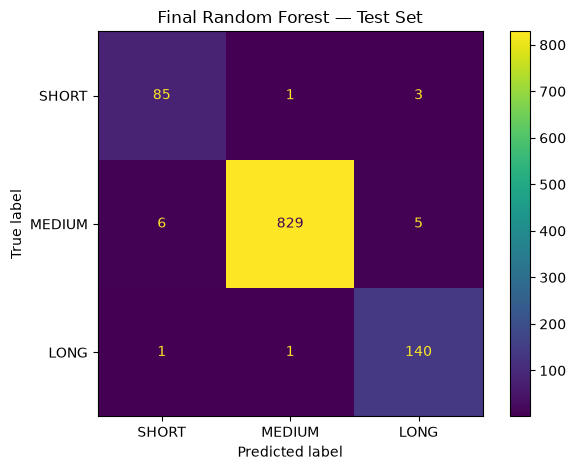

In [34]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    labels=["SHORT", "MEDIUM", "LONG"],
)

plt.title("Final Random Forest — Test Set")
plt.tight_layout()
plt.show()

The final Random Forest maintains its strong performance on the previously untouched test set.

Performance remains high across all three lifetime classes, including the minority `SHORT` and `LONG` categories. The final Random Forest maintains strong performance on the held-out test set. Because the dataset contains repeated satellite feature profiles, the additional robustness analysis distinguishes between repeated and previously unseen feature configurations, providing a more conservative view of model generalization.

### Robustness Check: Previously Unseen Feature Profiles

Many satellites share identical values across the selected modeling features, as can occur for standardized satellite families and constellation deployments.

The random split can therefore place satellites with identical feature profiles in both development and test sets. To assess whether the final performance depends primarily on these repeated profiles, we separately evaluate test observations whose exact feature vector was not present in the combined training and validation data.

This is a diagnostic analysis performed only after final model selection and test evaluation.

In [35]:
training_profiles = pd.MultiIndex.from_frame(
    X_final_train
)

test_profiles = pd.MultiIndex.from_frame(
    X_test
)

seen_profile_mask = test_profiles.isin(
    training_profiles
)

print(
    f"Test observations with a previously seen profile: "
    f"{seen_profile_mask.sum():,} "
    f"({100 * seen_profile_mask.mean():.1f}%)"
)

print(
    f"Test observations with a new profile: "
    f"{(~seen_profile_mask).sum():,} "
    f"({100 * (~seen_profile_mask).mean():.1f}%)"
)

Test observations with a previously seen profile: 649 (60.6%)
Test observations with a new profile: 422 (39.4%)


In [36]:
novel_profile_mask = ~seen_profile_mask

novel_profile_metrics = pd.Series({
    "Macro F1": f1_score(
        y_test[novel_profile_mask],
        y_pred_test[novel_profile_mask],
        average="macro",
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_test[novel_profile_mask],
        y_pred_test[novel_profile_mask],
    ),
})

display(
    novel_profile_metrics
    .round(4)
    .to_frame("Previously unseen profiles")
)

print(
    classification_report(
        y_test[novel_profile_mask],
        y_pred_test[novel_profile_mask],
        digits=3,
    )
)

,Previously unseen profiles
Macro F1,0.9556
Balanced Accuracy,0.9617


              precision    recall  f1-score   support

        LONG      0.939     0.984     0.961       126
      MEDIUM      0.990     0.948     0.968       210
       SHORT      0.921     0.953     0.937        86

    accuracy                          0.960       422
   macro avg      0.950     0.962     0.956       422
weighted avg      0.961     0.960     0.960       422



The test set contains substantial repetition in the selected feature representation: 60.6% of test observations have an exact feature profile already present in the combined training and validation data, while 39.4% represent previously unseen profiles.

Performance remains strong on the 422 unseen profiles, with a macro F1-score of 0.956 and balanced accuracy of 0.962. This indicates that the final Random Forest performance is not explained solely by exact repeated feature configurations.

This diagnostic is more conservative than the overall random-split evaluation, but it is not equivalent to a satellite-family-, constellation-, launch-, or time-disjoint benchmark. A group-aware or temporal split would therefore be a useful extension when evaluating generalization to entirely new satellite families or deployment regimes.


## Feature Importance

Random Forest provides an estimate of how much each input feature contributes to reducing classification impurity across its decision trees.

Because categorical variables were expanded into multiple one-hot encoded columns, their individual importances are aggregated back into the corresponding original feature. This makes the resulting ranking easier to interpret at the variable level.

These importances describe associations used by the model and should not be interpreted as causal effects.

In [37]:
feature_importance = pd.Series(
    final_rf.feature_importances_,
    index=X_final_train.columns,
    name="Importance",
)

def original_feature_name(feature):
    if feature.startswith("COUNTRY_GROUPED_"):
        return "COUNTRY_GROUPED"

    if feature.startswith("PURPOSE_GROUPED_"):
        return "PURPOSE_GROUPED"

    if feature.startswith("CLASS_OF_ORBIT_"):
        return "CLASS_OF_ORBIT"

    return feature


grouped_feature_importance = (
    feature_importance
    .groupby(feature_importance.index.map(original_feature_name))
    .sum()
    .sort_values(ascending=False)
)

display(
    grouped_feature_importance
    .round(4)
    .to_frame()
)

,Importance
LAUNCH_MASS_KG,0.2212
INCLINATION,0.1278
RCS_SIZE,0.1267
PERIGEE,0.1141
PERIOD,0.0873
LAUNCH_YEAR,0.0865
APOGEE,0.0800
PURPOSE_GROUPED,0.0707
CLASS_OF_ORBIT,0.0549
COUNTRY_GROUPED,0.0309


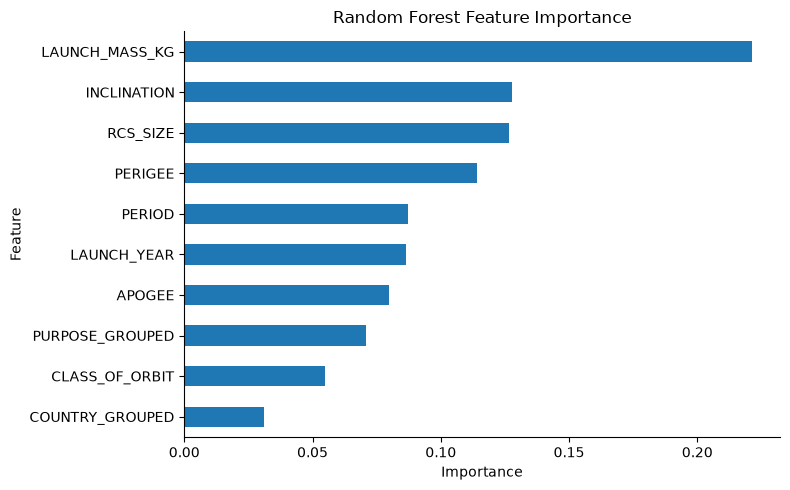

In [38]:
ax = (
    grouped_feature_importance
    .sort_values()
    .plot(
        kind="barh",
        figsize=(8, 5),
    )
)

ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Launch mass is the most influential feature in the final Random Forest, followed by several orbital characteristics such as inclination, perigee, and period.

Overall, the model relies more heavily on physical and orbital properties than on mission or country-related information. `PURPOSE_GROUPED` contributes some predictive information, whereas `COUNTRY_GROUPED` has comparatively little influence.

These values are impurity-based Random Forest feature importances. They indicate which variables the model finds useful for prediction, but they should not be interpreted as causal effects. Continuous variables can also receive relatively high importance because they offer many possible splitting points.

### Supervised Learning Summary

Three classification approaches were evaluated: Random Forest, XGBoost, and a calibrated RBF Support Vector Machine.

Random Forest achieved the strongest validation performance and was selected as the final model. After refitting it on the combined training and validation data, it achieved a test macro F1-score of 0.966 and balanced accuracy of 0.976.

Performance remained strong across all three lifetime classes. Because many satellites share identical selected feature profiles, an additional post-selection robustness check was performed on test observations whose exact feature vector was absent from the development data. The model retained a macro F1-score of 0.956 on this subset.

Feature-importance analysis suggests that the predictions are driven primarily by satellite mass and orbital characteristics.


## Unsupervised Learning

The second part of the analysis explores whether satellites form natural groups based on their physical and orbital characteristics.

Unlike the supervised task, clustering does not use `LIFETIME_CLASS`. The training, validation, and test subsets can therefore be recombined into a single dataset for this exploratory analysis.

We evaluate two complementary algorithms:

- **K-Means**, which partitions all observations into a predefined number of compact clusters;
- **DBSCAN**, which identifies dense regions without requiring the number of clusters in advance and can label atypical observations as noise.

In [39]:
all_features = pd.concat(
    [
        X_train,
        X_validation,
        X_test,
    ],
    ignore_index=True,
)

print(f"Clustering observations: {len(all_features):,}")

Clustering observations: 5,351


### Clustering Features and Distance Preparation

The clustering analysis uses only continuous physical and orbital characteristics:

- orbital period;
- inclination;
- apogee;
- perigee;
- launch mass.

Categorical variables are excluded because Euclidean-distance-based methods can be strongly affected by arbitrary numerical representations of categories. The lifetime target is also excluded so that the clusters reflect structure in the satellite characteristics themselves.

The exported numerical features were scaled for the supervised-learning split. For clustering, however, all 5,351 observations are analyzed together. A few extreme high-altitude or highly eccentric observations can dominate Euclidean distances and PCA, particularly for K-Means.

To reduce this effect without discarding any satellites, the upper 0.5% tail of the strongly right-skewed variables is capped at the 99.5th percentile. Inclination is left unchanged because it is naturally bounded. The resulting clustering variables are then rescaled jointly to the 0–1 range.

This transformation is specific to the unsupervised analysis and does not affect the supervised models.

In [40]:
clustering_features = [
    "PERIOD",
    "INCLINATION",
    "APOGEE",
    "PERIGEE",
    "LAUNCH_MASS_KG",
]

skewed_clustering_features = [
    "PERIOD",
    "APOGEE",
    "PERIGEE",
    "LAUNCH_MASS_KG",
]

CLIP_QUANTILE = 0.995

clustering_base = all_features[clustering_features].copy()

clip_limits = clustering_base[
    skewed_clustering_features
].quantile(CLIP_QUANTILE)

clustering_prepared = clustering_base.copy()

for feature in skewed_clustering_features:
    clustering_prepared[feature] = clustering_prepared[feature].clip(
        upper=clip_limits[feature]
    )

clustering_scaler = MinMaxScaler()

X_clustering = pd.DataFrame(
    clustering_scaler.fit_transform(clustering_prepared),
    columns=clustering_features,
    index=clustering_prepared.index,
)

display(
    clip_limits
    .rename("99.5th-percentile cap")
    .to_frame()
)

display(X_clustering.describe().round(3))

,99.5th-percentile cap
PERIOD,0.104429
APOGEE,0.120563
PERIGEE,0.706893
LAUNCH_MASS_KG,0.330592


,PERIOD,INCLINATION,APOGEE,PERIGEE,LAUNCH_MASS_KG
count,5351.000,5351.000,5351.000,5351.000,5351.000
mean,0.113,0.389,0.120,0.118,0.103
std,0.291,0.166,0.289,0.289,0.193
min,0.000,0.000,0.000,0.000,0.000
25%,0.008,0.346,0.015,0.015,0.039
50%,0.009,0.347,0.015,0.015,0.039
75%,0.012,0.564,0.021,0.021,0.044
max,1.000,1.000,1.000,1.000,1.000


### K-Means

K-Means requires the number of clusters, $k$, to be specified in advance.

We compare **inertia**, which measures within-cluster dispersion, and the **silhouette score**, which measures separation between clusters. These criteria are considered together rather than selecting $k$ mechanically from a single score.

In [41]:
possible_ks = range(2, 13)

inertia = []
silhouette_scores = []

for k in possible_ks:
    candidate_kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_SEED,
        n_init="auto",
    )

    candidate_labels = candidate_kmeans.fit_predict(X_clustering)

    inertia.append(candidate_kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(
            X_clustering,
            candidate_labels,
        )
    )

kmeans_evaluation = pd.DataFrame({
    "k": list(possible_ks),
    "Inertia": inertia,
    "Silhouette": silhouette_scores,
})

display(kmeans_evaluation.round(4))

,k,Inertia,Silhouette
0,2,242.2178,0.8767
1,3,177.3209,0.7455
2,4,84.1982,0.7646
3,5,62.5663,0.7530
4,6,44.6218,0.7708
5,7,39.6583,0.7659
6,8,36.0759,0.7492
7,9,26.6668,0.7523
8,10,25.0715,0.7521
9,11,23.3461,0.7417


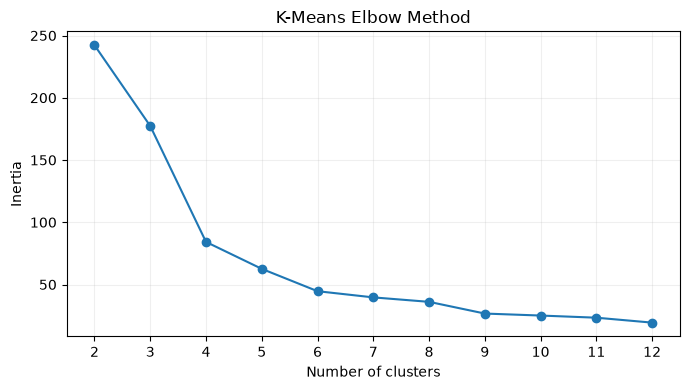

In [42]:
plt.figure(figsize=(7, 4))

plt.plot(
    possible_ks,
    inertia,
    marker="o",
)

plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.xticks(list(possible_ks))
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

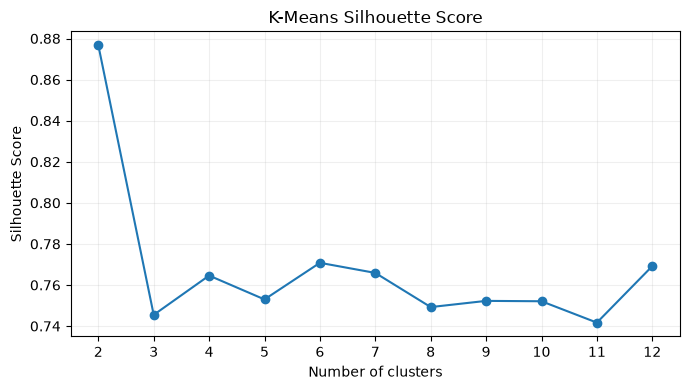

In [43]:
plt.figure(figsize=(7, 4))

plt.plot(
    possible_ks,
    silhouette_scores,
    marker="o",
)

plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score")
plt.xticks(list(possible_ks))
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

The silhouette score is highest for the very coarse two-cluster solution, but the inertia curve shows a substantial improvement by $k=4$. The four-cluster solution also preserves meaningful orbital structure rather than merging the main regimes into only two broad groups.

We therefore select **$k=4$** as a balance between separation, compactness, and interpretability.

In [44]:
K = 4

kmeans = KMeans(
    n_clusters=K,
    random_state=RANDOM_SEED,
    n_init="auto",
)

kmeans_clusters = kmeans.fit_predict(X_clustering)

cluster_sizes = (
    pd.Series(kmeans_clusters)
    .value_counts()
    .sort_index()
    .rename("Satellites")
    .to_frame()
)

cluster_sizes.index.name = "Cluster"

display(cluster_sizes)

,Satellites
Cluster,
0,3291
1,490
2,1426
3,144


In [45]:
orbit_columns = [
    column
    for column in all_features.columns
    if column.startswith("CLASS_OF_ORBIT_")
]

orbit_class = (
    all_features[orbit_columns]
    .idxmax(axis=1)
    .str.replace("CLASS_OF_ORBIT_", "", regex=False)
)

cluster_orbit_pct = (
    pd.crosstab(
        kmeans_clusters,
        orbit_class,
        normalize="index",
    )
    .mul(100)
    .round(1)
)

cluster_orbit_pct.index.name = "Cluster"
cluster_orbit_pct.columns.name = "Orbit Class"

display(cluster_orbit_pct)

Orbit Class,ELLIPTICAL,GEO,LEO,MEO
Cluster,,,,
0,0.0,0.2,99.8,0.0
1,0.6,99.4,0.0,0.0
2,0.2,0.0,99.8,0.0
3,18.1,0.0,0.0,81.9


The four-cluster solution closely reflects the known orbital regimes even though orbit class is not used as a clustering input.

Two clusters are composed almost entirely of LEO satellites, revealing substructure within the dominant low-Earth-orbit population. A third cluster is almost entirely GEO, while the fourth is dominated by MEO satellites and contains part of the small elliptical population.

This is qualitatively similar to the expected orbital organization while still allowing K-Means to identify more than one characteristic LEO population.

#### PCA Visualization

To visualize the clustering structure, the five-dimensional feature space is projected onto two principal components.

PCA is used only for visualization: K-Means is fitted in the complete five-dimensional clustering space.

In [46]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_clustering)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
)

pca_df["Cluster"] = kmeans_clusters

explained_variance = (
    pca.explained_variance_ratio_.sum() * 100
)

print(
    f"Variance explained by the first two PCs: "
    f"{explained_variance:.1f}%"
)

Variance explained by the first two PCs: 96.0%


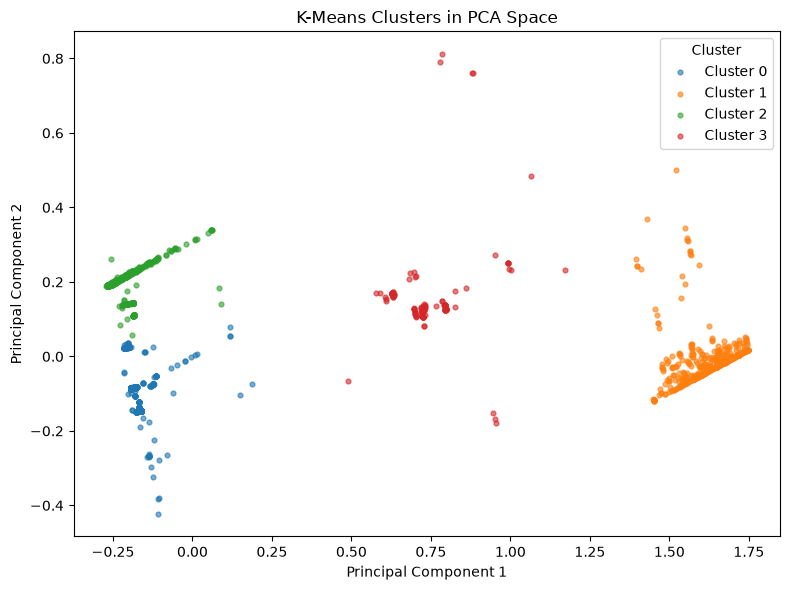

In [47]:
plt.figure(figsize=(8, 6))

for cluster in sorted(pca_df["Cluster"].unique()):
    cluster_data = pca_df.loc[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        s=12,
        alpha=0.6,
        label=f"Cluster {cluster}",
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters in PCA Space")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

The first two principal components preserve most of the variance in the prepared clustering space. The projection shows four visually distinct populations, consistent with the orbit-class comparison: two LEO-dominated groups, one GEO-dominated group, and one group dominated by MEO satellites.

The small number of unusual elliptical objects remains more difficult to represent with compact centroid-based clusters, motivating the complementary DBSCAN analysis below.

### DBSCAN

DBSCAN provides a complementary density-based view of the same clustering space.

Instead of assigning every satellite to a cluster, DBSCAN can label observations in sparse regions as noise. This is useful for rare or highly unusual orbital configurations.

We use `min_samples = 10` and inspect the distance to each observation's 10th nearest neighbor to select a reasonable neighborhood radius, `eps`.

In [48]:
min_samples = 10

neighbors = NearestNeighbors(
    n_neighbors=min_samples,
)

neighbors.fit(X_clustering)

distances, _ = neighbors.kneighbors(X_clustering)

k_distances = np.sort(
    distances[:, -1]
)

quantiles = [
    0.90,
    0.95,
    0.97,
    0.98,
    0.99,
    0.995,
    0.999,
]

k_distance_quantiles = pd.Series(
    {
        f"{q:.1%}": np.quantile(k_distances, q)
        for q in quantiles
    },
    name="10th-neighbor distance",
)

display(k_distance_quantiles.to_frame())

,10th-neighbor distance
90.0%,0.012709
95.0%,0.026732
97.0%,0.044079
98.0%,0.064201
99.0%,0.159679
99.5%,0.302489
99.9%,0.693413


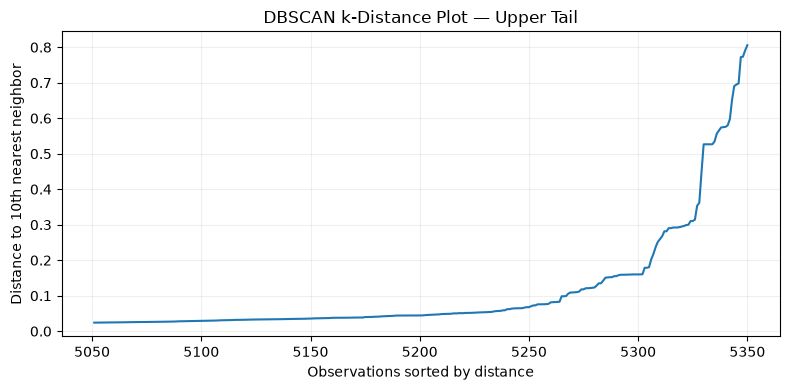

In [49]:
last_n = 300

plt.figure(figsize=(8, 4))

plt.plot(
    np.arange(
        len(k_distances) - last_n,
        len(k_distances),
    ),
    k_distances[-last_n:],
)

plt.xlabel("Observations sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.title("DBSCAN k-Distance Plot — Upper Tail")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

The upper tail of the k-distance curve begins to rise rapidly around the neighborhood scale of interest. Rather than choosing `eps` from a single visual estimate, we compare a small range around this transition.

In [50]:
eps_values = [
    0.12,
    0.15,
    0.18,
    0.20,
    0.25,
    0.30,
]

dbscan_results = []

for eps in eps_values:
    candidate_dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples,
    )

    labels = candidate_dbscan.fit_predict(X_clustering)

    non_noise_mask = labels != -1

    n_clusters = len(
        set(labels) - {-1}
    )

    n_noise = (labels == -1).sum()
    noise_pct = 100 * n_noise / len(labels)

    if n_clusters > 1:
        silhouette = silhouette_score(
            X_clustering.loc[non_noise_mask],
            labels[non_noise_mask],
        )
    else:
        silhouette = np.nan

    dbscan_results.append({
        "eps": eps,
        "Clusters": n_clusters,
        "Noise": n_noise,
        "Noise (%)": noise_pct,
        "Silhouette": silhouette,
    })

dbscan_evaluation = pd.DataFrame(
    dbscan_results
)

display(dbscan_evaluation.round(4))

,eps,Clusters,Noise,Noise (%),Silhouette
0,0.12,5,61,1.1400,0.7898
1,0.15,4,59,1.1026,0.7998
2,0.18,3,35,0.6541,0.8330
3,0.20,3,34,0.6354,0.8328
4,0.25,3,24,0.4485,0.8324
5,0.30,3,23,0.4298,0.8321


A neighborhood radius around `eps = 0.20` provides a stable and interpretable solution: the main dense orbital populations remain separate, only a small fraction of observations is labeled as noise, and the silhouette score remains high.

We therefore use **`eps = 0.20`** for the final DBSCAN model.

In [51]:
DBSCAN_EPS = 0.20

dbscan = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=min_samples,
)

dbscan_clusters = dbscan.fit_predict(
    X_clustering
)

dbscan_cluster_sizes = (
    pd.Series(dbscan_clusters)
    .value_counts()
    .sort_index()
    .rename("Satellites")
    .to_frame()
)

dbscan_cluster_sizes.index.name = "Cluster"

display(dbscan_cluster_sizes)

n_dbscan_clusters = len(
    set(dbscan_clusters) - {-1}
)

n_noise = (dbscan_clusters == -1).sum()

print(f"Clusters: {n_dbscan_clusters}")
print(
    f"Noise observations: {n_noise} "
    f"({100 * n_noise / len(dbscan_clusters):.2f}%)"
)

,Satellites
Cluster,
-1,34
0,4712
1,487
2,118


Clusters: 3
Noise observations: 34 (0.64%)


In [52]:
dbscan_orbit_pct = (
    pd.crosstab(
        dbscan_clusters,
        orbit_class,
        normalize="index",
    )
    .mul(100)
    .round(1)
)

dbscan_orbit_pct.index.name = "Cluster"
dbscan_orbit_pct.columns.name = "Orbit Class"

display(dbscan_orbit_pct)

Orbit Class,ELLIPTICAL,GEO,LEO,MEO
Cluster,,,,
-1,76.5,8.8,5.9,8.8
0,0.1,0.1,99.9,0.0
1,0.2,99.8,0.0,0.0
2,1.7,0.0,0.0,98.3


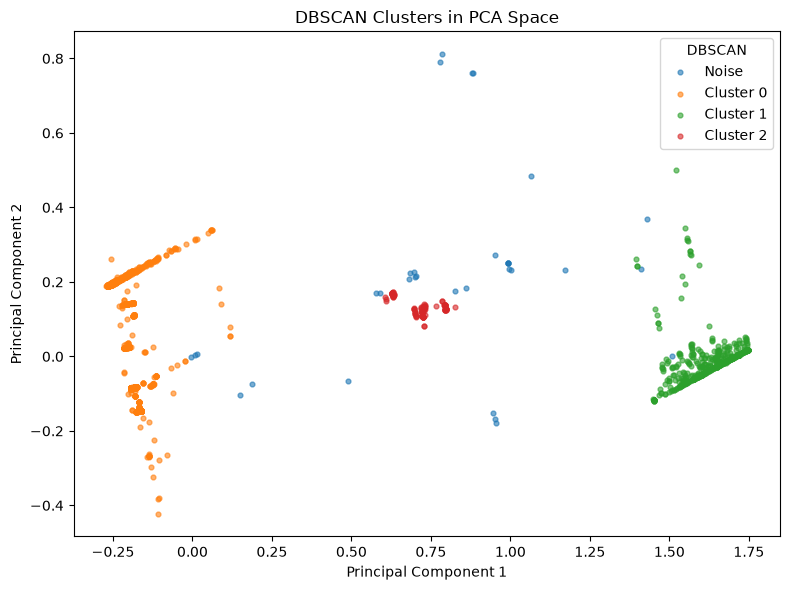

In [53]:
dbscan_pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
)

dbscan_pca_df["Cluster"] = dbscan_clusters

plt.figure(figsize=(8, 6))

for cluster in sorted(
    dbscan_pca_df["Cluster"].unique()
):
    cluster_data = dbscan_pca_df.loc[
        dbscan_pca_df["Cluster"] == cluster
    ]

    label = (
        "Noise"
        if cluster == -1
        else f"Cluster {cluster}"
    )

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        s=12,
        alpha=0.6,
        label=label,
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clusters in PCA Space")
plt.legend(title="DBSCAN")

plt.tight_layout()
plt.show()

DBSCAN recovers three main dense populations corresponding closely to LEO, GEO, and MEO satellites.

Unlike K-Means, it does not force the unusual elliptical observations into compact centroid-based groups. Instead, the noise population is strongly enriched in elliptical orbits, showing that many of these satellites occupy relatively sparse regions of the physical-orbital feature space.

The two algorithms therefore provide complementary descriptions: K-Means highlights substructure within LEO, whereas DBSCAN emphasizes the three main dense orbital regimes and isolates atypical configurations.

### Clustering Comparison

In [54]:
kmeans_silhouette = silhouette_score(
    X_clustering,
    kmeans_clusters,
)

dbscan_non_noise = dbscan_clusters != -1

dbscan_silhouette = silhouette_score(
    X_clustering.loc[dbscan_non_noise],
    dbscan_clusters[dbscan_non_noise],
)

clustering_summary = pd.DataFrame({
    "Method": ["K-Means", "DBSCAN"],
    "Clusters": [
        len(np.unique(kmeans_clusters)),
        n_dbscan_clusters,
    ],
    "Noise observations": [
        0,
        n_noise,
    ],
    "Noise (%)": [
        0.0,
        100 * n_noise / len(dbscan_clusters),
    ],
    "Silhouette": [
        kmeans_silhouette,
        dbscan_silhouette,
    ],
})

display(clustering_summary.round(4))

,Method,Clusters,Noise observations,Noise (%),Silhouette
0,K-Means,4,0,0.0000,0.7646
1,DBSCAN,3,34,0.6354,0.8328


K-Means and DBSCAN recover a consistent large-scale orbital structure while emphasizing different aspects of the data.

K-Means produces four clusters, separating the LEO population into two characteristic groups while also identifying GEO and predominantly MEO populations. DBSCAN instead finds three dense orbital regimes and treats a small set of unusual observations as noise.

The DBSCAN silhouette is calculated only for non-noise observations, so it should be treated as a descriptive reference rather than a directly equivalent model-selection score.

## Conclusions

This analysis combined supervised and unsupervised machine-learning methods to study satellite characteristics and reported expected lifetime.

For the supervised task, Random Forest, XGBoost, and a calibrated RBF Support Vector Machine were compared using macro F1-score, balanced accuracy, and multiclass ROC-AUC. Random Forest achieved the strongest validation performance and was selected as the final model. After refitting on the combined training and validation data, it achieved a test macro F1-score of 0.966 and balanced accuracy of 0.976.

Performance remained strong across all three lifetime classes. A robustness check also showed a macro F1-score of 0.956 on test observations whose exact feature profiles were absent from the development data, reducing the concern that the final score is driven only by repeated feature configurations. A stricter group-aware or temporal split would be a natural extension for testing generalization to entirely new satellite families or deployment regimes.

Feature-importance analysis showed that launch mass and orbital characteristics contributed most strongly to the Random Forest predictions.

For the unsupervised analysis, the clustering representation was made robust to a small number of extreme orbital values without removing observations. K-Means identified four interpretable groups: two LEO-dominated populations, one GEO-dominated population, and one predominantly MEO group. DBSCAN recovered the three main dense orbital regimes while identifying a small set of atypical observations, many associated with elliptical orbits.

Together, these results show that satellite physical and orbital characteristics contain strong structure that is useful both for lifetime classification and for identifying natural groups within the satellite population.
